<a href="https://colab.research.google.com/github/Janajeevi/CN7030-ASSIGNMENT-2-/blob/main/Week7%20(email).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark
from pyspark.sql import SparkSession

# Initialize Spark Session
spark = SparkSession.builder.appName('EmailSpamClassification').getOrCreate()
print('Spark Session created.')

Spark Session created.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

from pyspark.ml.functions import vector_to_array

from sklearn.metrics import confusion_matrix

In [2]:
spark = SparkSession.builder \
    .appName("Email Spam Classification") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
# print("Upload emails.csv")

# uploaded = files.upload()

# file_name = list(uploaded.keys())[0]

# print("Uploaded:", file_name)

In [6]:
import re
from pyspark.sql import SparkSession

# Ensure SparkSession is available
spark = SparkSession.builder.getOrCreate()

# Load dataset
file_name = '/content/emails.csv'
df = spark.read.csv(
    file_name,
    header=True,
    inferSchema=True
)

# Rename all columns: remove spaces, dots, and COMMAS which cause Spark ML issues
new_columns = [re.sub(r'[ .,]', '_', c) for c in df.columns]
df = df.toDF(*new_columns)

print("Rows:", df.count())
print("Columns:", len(df.columns))

df.show(5)

Rows: 9653
Columns: 3002
+---------+---+---+---+---+---+---+---+---+---+---+---+---+----+-----+---+---+----+----+----+----+----+---+---+---+---+---+---+---+---+----+---+---+---+---+----+---+-----+---+------+---+---+---+---+----+---+---+---+---+---+----+----+---+---------+---+---+---+---+---+-----+------+---+---+---+---+---+---+-----+-----+-----+---+----+-------+---+-----+---+---+-----+---+----+---+------+--------+---+-----------+----+-------+---+----+---+---+----+----+----+---+------+----+--------+-----+-----+----+------+------+-----+-----+---+------+---+---------+---+-----+-------+---+---+---+-----+----+----+-----+----+----+----+------+-----+----+----+---+----+---+---------+---+----------+----+----+----+----+--------+----+-----+---+------+---+---+-----+----+---+------+-----+-------+----+----+----+----------+------+---+-----+------+----+---+---+-----+------+--------+----+---+-------+----+-------+----+----+-----+---+-----+-----+---+---+---+---+-----+----------+---+----+---+----+-----+--

In [7]:
df.printSchema()

# Selecting only a subset of columns for describe to avoid the AnalysisException caused by 3000+ columns
subset_cols = ["Prediction"] + df.columns[1:11]
df.select(subset_cols).describe().show()

print("Spam and Ham Distribution")
df.groupBy("Prediction").count().show()

root
 |-- Email_No_: string (nullable = true)
 |-- the: integer (nullable = true)
 |-- to: integer (nullable = true)
 |-- ect: integer (nullable = true)
 |-- and: integer (nullable = true)
 |-- for: integer (nullable = true)
 |-- of: integer (nullable = true)
 |-- a: integer (nullable = true)
 |-- you: integer (nullable = true)
 |-- hou: integer (nullable = true)
 |-- in: integer (nullable = true)
 |-- on: integer (nullable = true)
 |-- is: integer (nullable = true)
 |-- this: integer (nullable = true)
 |-- enron: integer (nullable = true)
 |-- i: integer (nullable = true)
 |-- be: integer (nullable = true)
 |-- that: integer (nullable = true)
 |-- will: integer (nullable = true)
 |-- have: integer (nullable = true)
 |-- with: integer (nullable = true)
 |-- your: integer (nullable = true)
 |-- at: integer (nullable = true)
 |-- we: integer (nullable = true)
 |-- s: integer (nullable = true)
 |-- are: integer (nullable = true)
 |-- it: integer (nullable = true)
 |-- by: integer (nullabl

In [8]:
df = df.dropna()

print("Rows after cleaning:", df.count())

Rows after cleaning: 9625


In [11]:
import re
from pyspark.ml.feature import VectorAssembler

# Exclude non-numeric and target columns
# 'Email_No_' is a string identifier, 'Prediction' is the label
exclude_cols = ["Email_No_", "Prediction", "features"]

# Filter columns to only include word count columns (numeric)
all_word_cols = [c for c in df.columns if c not in exclude_cols]

# Select the first 500 numeric word features to prevent memory issues
feature_columns = all_word_cols[:500]

# Drop 'features' column if it already exists to avoid duplication errors
if "features" in df.columns:
    df = df.drop("features")

# Initialize the VectorAssembler
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

# Transform the data
email_df = assembler.transform(df)

# Select the label and the features vector for modeling
email_df = email_df.select("Prediction", "features")

print(f"Using {len(feature_columns)} features.")
email_df.show(5)

Using 500 features.
+----------+--------------------+
|Prediction|            features|
+----------+--------------------+
|         0|(500,[2,6,11,14,2...|
|         0|(500,[0,1,2,3,4,5...|
|         0|(500,[2,6,9,10,14...|
|         0|(500,[1,2,4,5,6,7...|
|         0|(500,[0,1,2,3,4,5...|
+----------+--------------------+
only showing top 5 rows


In [12]:
train_data, test_data = email_df.randomSplit([0.8,0.2], seed=42)

print("Training:", train_data.count())
print("Testing :", test_data.count())

Training: 7755
Testing : 1870


In [13]:
# Repartition the data to handle memory pressure from high-dimensional features
train_data_repartitioned = train_data.repartition(10)

nb = NaiveBayes(
    labelCol="Prediction",
    featuresCol="features",
    modelType="multinomial"
)

# Fit the model using the repartitioned data
model = nb.fit(train_data_repartitioned)
print("Model training complete.")

Model training complete.


In [14]:
predictions = model.transform(test_data)

predictions.select(
    "Prediction",
    "prediction",
    "probability"
).show(20, truncate=False)

+----------+----------+-----------------------------+
|Prediction|prediction|probability                  |
+----------+----------+-----------------------------+
|0.0       |0.0       |[1.0,0.0]                    |
|0.0       |0.0       |[1.0,0.0]                    |
|0.0       |0.0       |[1.0,9.057190905844728E-203] |
|0.0       |0.0       |[1.0,2.4899915483084065E-117]|
|0.0       |0.0       |[1.0,6.479489610718909E-48]  |
|0.0       |0.0       |[1.0,2.5075156563491132E-116]|
|0.0       |0.0       |[1.0,4.0255913125406926E-22] |
|1.0       |1.0       |[2.0255234230332966E-52,1.0] |
|0.0       |0.0       |[1.0,9.092841749623554E-89]  |
|0.0       |0.0       |[1.0,9.092841749623554E-89]  |
|0.0       |0.0       |[1.0,6.325311314006461E-164] |
|0.0       |0.0       |[1.0,5.610691883846908E-64]  |
|1.0       |1.0       |[5.041580406846403E-45,1.0]  |
|0.0       |0.0       |[1.0,5.135717240506931E-264] |
|0.0       |0.0       |[1.0,1.7610152478926381E-131]|
|0.0       |0.0       |[1.0,

In [15]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="accuracy"
)

acc = accuracy.evaluate(predictions)

print("Accuracy =", acc)

Accuracy = 1.0


In [16]:
precision = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

print("Precision =", precision.evaluate(predictions))

Precision = 1.0


In [17]:
recall = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Recall =", recall.evaluate(predictions))

Recall = 1.0


In [18]:
f1 = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="f1"
)

print("F1 Score =", f1.evaluate(predictions))

F1 Score = 1.0


In [19]:
prob = predictions.withColumn(
    "prob",
    vector_to_array("probability")[1]
)

evaluator = BinaryClassificationEvaluator(
    labelCol="Prediction",
    rawPredictionCol="prob",
    metricName="areaUnderROC"
)

roc = evaluator.evaluate(prob)

print("ROC-AUC =", roc)

ROC-AUC = 1.0


In [20]:
pred_pd = predictions.select(
    "Prediction",
    "prediction"
).toPandas()

cm = confusion_matrix(
    pred_pd["Prediction"],
    pred_pd["prediction"]
)

print(cm)

[[1228    0]
 [   0  642]]


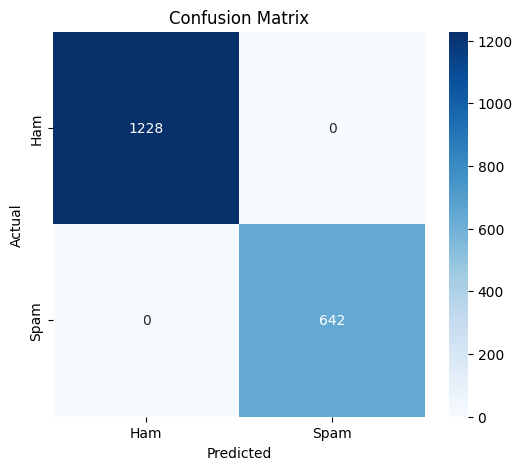

In [21]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [22]:
theta = model.theta.toArray()

spam_weights = theta[1]

importance = pd.DataFrame({
    "Word": feature_columns,
    "Weight": spam_weights
})

importance = importance.sort_values(
    by="Weight",
    ascending=False
)

importance.head(20)

,Word,Weight
40,e,-2.447280
54,t,-2.766495
6,a,-2.810000
138,o,-2.818494
14,i,-2.855991
275,n,-2.955497
173,r,-2.978240
23,s,-3.034106
72,l,-3.392927
140,c,-3.480086


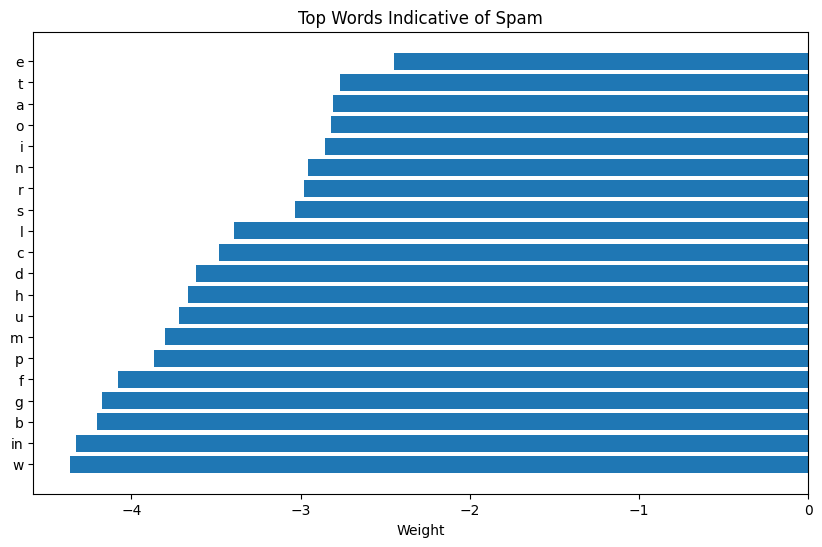

In [23]:
top = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(top["Word"], top["Weight"])

plt.gca().invert_yaxis()

plt.title("Top Words Indicative of Spam")

plt.xlabel("Weight")

plt.show()

In [24]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

paramGrid = ParamGridBuilder() \
    .addGrid(nb.smoothing,[0.5,1.0,1.5,2.0]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="accuracy"
)

tvs = TrainValidationSplit(
    estimator=nb,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.8
)

tuned_model = tvs.fit(train_data)

best_model = tuned_model.bestModel

pred = best_model.transform(test_data)

print(
    "Best Accuracy =",
    evaluator.evaluate(pred)
)

print(
    "Best Smoothing =",
    best_model.getSmoothing()
)

Best Accuracy = 1.0
Best Smoothing = 0.5
